# Blackbox Optimisation Project: Phase 1.3

This code builds to Pahse 1.2s classification of "promising" regions by adding further fucntionality for bounding the search space. Descriptive statistics are calculated to understand the presence and sharpness of localised regions of promise <br> -- If a sharp peak is present, bound the search for a new point by a distance from that peak <br> -- If there is a clearly localised region of \tpromise, but no obvious peak, fit an SVM and bound the searhc space by its decision boundary <br>-- otherwise, continue to use the convex hull defined in phase 1.2 

In [164]:
week = 13
function = 1

Import Standard Libraries

In [165]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path

import matplotlib.pyplot as plt

Import Project Packages

In [166]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

### Import and Update Data

In [167]:
print(f"Requested function {function} in week {week}")

print("\nData Loading")

# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)

# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)

# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)

# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"\tresults will be saved to {results_dir}...")

print("\nData Preprocessing")
input_cols = data_loading.get_X_cols(df)

print("\t scaling outputs")
df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])

print("\tclassify promising regions")
quantile = 0.75
threshold = df["YScaled"].quantile(quantile)

while (df["YScaled"] >= threshold).astype(int).sum() < len(input_cols) + 1:
    quantile = quantile - 0.05
    threshold = df["YScaled"].quantile(quantile)

    print(quantile)

df["promising"] = (df["YScaled"] >= threshold).astype(int)

print("separating inputs and outputs")

df_inputs = df[input_cols]
df_output = df["YScaled"]

N = len(df)
nN = len(df[df["new data point"] == 1])

print(f"\nTotal number of data points {N}")
print(f"number of new data points {nN}")

print(f"\n Current Max, Min Values: {df['Y1'].max():.6f},{df['Y1'].min():.6f}")

Requested function 1 in week 13

Data Loading
	Loaded initial data: function_1
	Available update files:
		1: new_data_point_wk1.csv
		2: new_data_point_wk10.csv
		3: new_data_point_wk11.csv
		4: new_data_point_wk12.csv
		5: new_data_point_wk2.csv
		6: new_data_point_wk3.csv
		7: new_data_point_wk4.csv
		8: new_data_point_wk5.csv
		9: new_data_point_wk6.csv
		10: new_data_point_wk7.csv
		11: new_data_point_wk8.csv
		12: new_data_point_wk9.csv
	Added 12 new data points.
	results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_13\function_1...

Data Preprocessing
	 scaling outputs
	classify promising regions
separating inputs and outputs

Total number of data points 22
number of new data points 12

 Current Max, Min Values: 0.044896,-0.006092


In [168]:
df

,X1,X2,Y1,new data point,YScaled,promising
0,0.319404,0.762959,1.322677e-79,0,0.119484,1
1,0.574329,0.879898,1.033078e-46,0,0.119484,1
2,0.731024,0.733000,7.710875e-16,0,0.119484,1
3,0.840353,0.264732,3.341771e-124,0,0.119484,1
4,0.650114,0.681526,-3.606063e-03,0,0.048760,0
5,0.410437,0.147554,-2.159249e-54,0,0.119484,1
6,0.312691,0.078723,-2.089093e-91,0,0.119484,1
7,0.683418,0.861057,2.535001e-40,0,0.119484,1
8,0.082507,0.403488,3.606771e-81,0,0.119484,1
9,0.883890,0.582254,6.229856e-48,0,0.119484,1


### Descriptive Statistics

In [169]:
med = df["YScaled"].median()
Q3 = df["YScaled"].quantile(0.75)
Q1 = df["YScaled"].quantile(0.25)
IQR = Q3 - Q1

Calculate number of outliers and how localised they are

In [170]:
upper_bound = Q3 + 1.5*IQR
num_data_outside_bound = (df["YScaled"] > upper_bound).sum()

if function == 1:
    choice = 1

elif IQR > 0.01:

    if num_data_outside_bound > 0:

        volume_fraction, rouge_points, promising_points = data_augmentation.subset_volume(df,input_cols,upper_bound)
        choice = 1
        
        print(f"{num_data_outside_bound} outliers spread acorss {volume_fraction:.1f}% of the domain")
    else:
        # num_data_above_Q3 = (df_promising["YScaled"] > Q3).sum()
        choice = 2

        volume_fraction, rouge_points, promising_points = data_augmentation.subset_volume(df,input_cols,Q3)

        if volume_fraction > 35:
            choice = 2
        else:
            choice = 3
        
        print("No outliers")
        print(f"{promising_points} data points in upper quartile spread acorss {volume_fraction:.1f}% of the domain")
        print(f"{rouge_points} data points within promising volume, but not in upper quartile")

else:
    choice = 0
    print("Data set too poorly distributed for modelling")

### Augment data set

Define Search Space
<br>-- The search space for a new point is bound by a convex hull
<br>-- The space enclosed by that convex hull can be controlled by choing different options below

In [171]:
sample_size = int(1e5)
points = df_inputs.to_numpy()

if choice == 0:
    df_hull_inputs = df_inputs.copy()

elif choice == 1:
    max_idx = df['YScaled'].idxmax()
    max_point = df.loc[max_idx]

    center = max_point[input_cols].values.astype(float)

    print(f"Generating sampling {sample_size} random samples within Latin Hypercube ...")
    X = df[input_cols].to_numpy()
    lhc_samples = data_augmentation.generate_lhc(X.shape[1], n_samples=sample_size)
    df_lhc = pd.DataFrame(lhc_samples, columns=input_cols)

    lhc_points = df_lhc[input_cols].values.astype(float)

    r = 0.025
    num_points_inside = 0
    while num_points_inside < (len(input_cols)*2):
        r += 0.05
        distances = np.linalg.norm(lhc_points - center, axis=1)

        # Points inside n-dimensional sphere
        inside_mask = distances <= r
        df_hull_inputs = df_lhc[inside_mask]
        num_points_inside = len(df_hull_inputs)
        
        
else:
    print("classifying promising data points...")

    quantile = 0.85
    threshold = df["YScaled"].quantile(quantile)

    while (df["YScaled"] >= threshold).astype(int).sum() < len(input_cols) + 1:
        quantile = quantile - 0.05
        threshold = df["YScaled"].quantile(quantile)

    df["promising"] = (df["YScaled"] >= threshold).astype(int)
    print(f"\tpromising data points classified with a threshold value of {quantile}...")   

    if choice == 2:
        df_hull = df[df["promising"] == 1]
        df_hull_inputs = df_hull[input_cols]
    
    elif choice == 3:
        df_svm = df.drop(columns=["Y1", "new data point", "YScaled"])
        X = df_svm[input_cols].to_numpy()

        print(f"Generating sampling {sample_size} random samples within Latin Hypercube ...")
        lhc_samples = data_augmentation.generate_lhc(X.shape[1], n_samples=sample_size)
        df_lhc = pd.DataFrame(lhc_samples, columns=input_cols)
        
        print(f"Using SVM to define decision boundary...")
        
        df_svm = df.drop(columns=["Y1", "new data point", "YScaled"])
        df_lhc = pd.DataFrame(lhc_samples, columns=input_cols)
        
        df_modelled = data_augmentation.augment_with_svm(df_svm, df_lhc, lhc_samples, input_cols, results_dir)

        df_hull_inputs = df_modelled[input_cols]   

Generating sampling 100000 random samples within Latin Hypercube ...


In [ ]:
print(f"Calaculating Convex Hull around chosen data set...")
hull, points_hull = data_augmentation.compute_convex_hull(df_hull_inputs)

print(f"Finding random sample within search space that is the furthest Euclidian distance from all input data points...")
best_point, best_dist = data_augmentation.most_isolated_point(points_hull, hull, n_samples=sample_size, seed=42)
best_point_dict = {col: val for col, val in zip(input_cols, best_point)}

Calaculating Convex Hull around chosen data set...
Finding random sample within search space that is the furthest Euclidian distance from all input data points...
	generating random seeds...
	finding internal points...
	looking for furthest points...


: 

### Plot Results

In [159]:
new_point_flag = df["new data point"].to_numpy()

X = df_inputs.to_numpy()
Y = df_output.to_numpy()

Y = np.asarray(Y).reshape(-1, 1)

try:
    Z = df["promising"].to_numpy().reshape(-1, 1)
except:
    Z = np.zeros(len(Y)) 

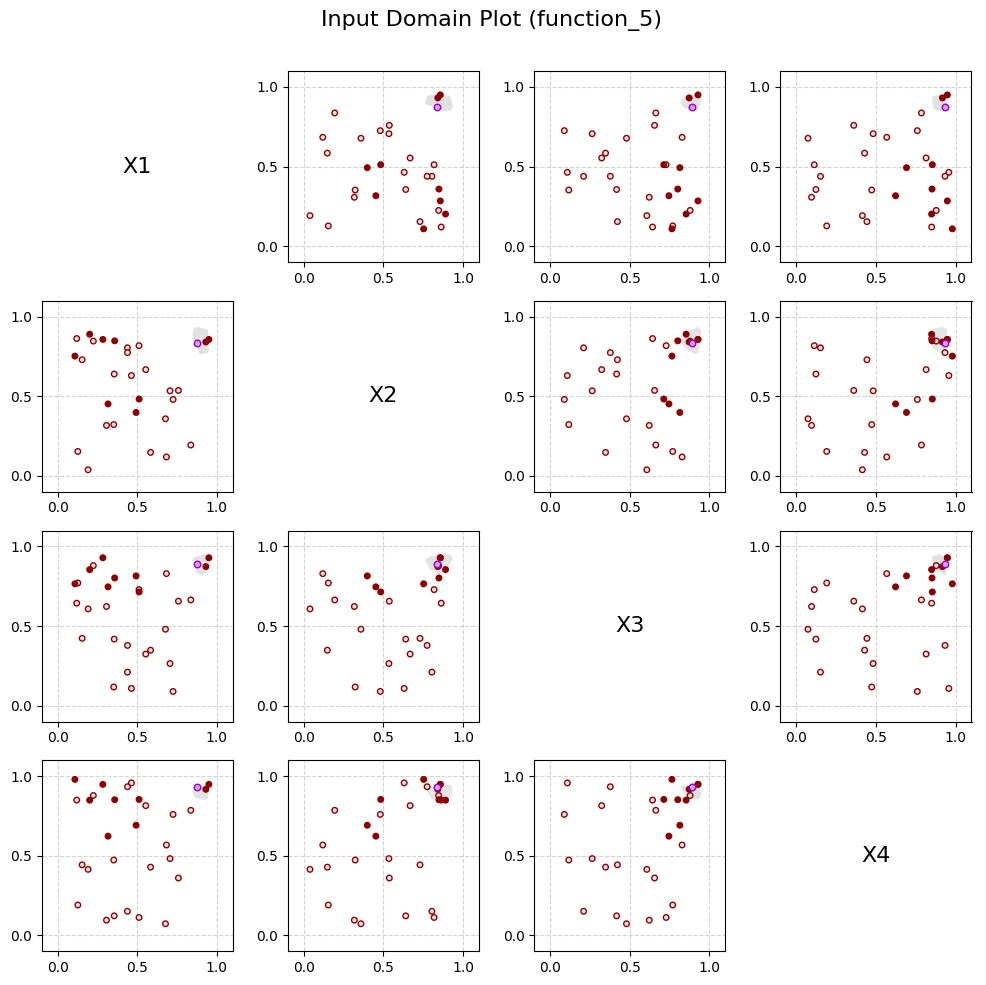

In [160]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, X, points_hull, new_point_flag, hull = hull,next_point = best_point_dict)

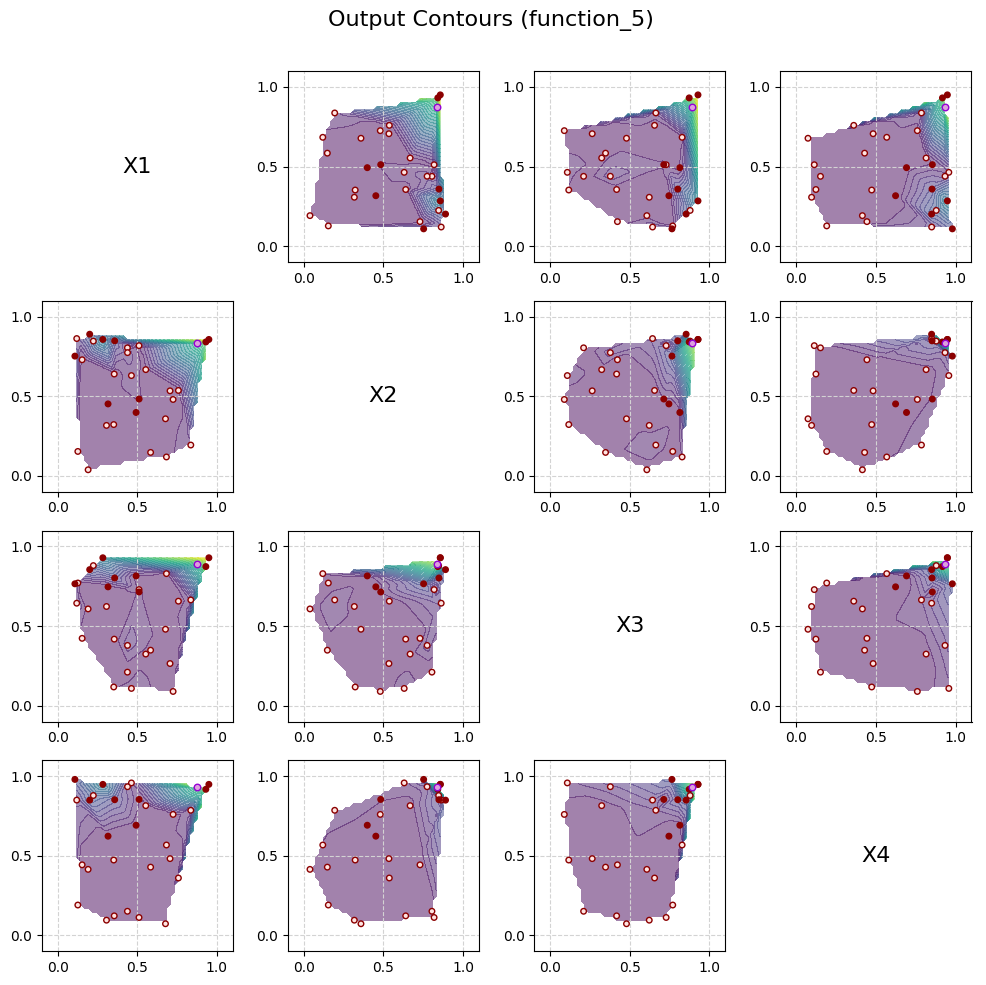

In [161]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_hull, new_point_flag, contour = Y[:, 0],next_point = best_point_dict)

write results to csv

write results to csv

In [162]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [163]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.875370-0.833712-0.891308-0.933383
